# Sliding-Window Pairwise Electrode Correlation

Compute a time-resolved `n_ch x n_ch` zero-lag Pearson correlation matrix for each of BLT, P1, and P2 (500 ms gap only), on a shared time axis, then compare.

- Signal per condition: trial-averaged evoked.
- Window: `WINDOW_MS` ms, step `STEP_MS` ms.
- Output per condition: `(n_windows, n_ch, n_ch)` + window-center times.

## A. Setup & config

In [68]:
import numpy as np
import matplotlib.pyplot as plt

from utils import load_eeg_data
from connectivity import (
    select_p2_500ms,
    sliding_corr_from_epochs,
    summary_metrics,
    lagged_corr_2d,
    sliding_lagged_diff_corr_from_epochs
)

SUBJECT = 5
TMIN, TMAX = None, None       # native epoch window (must match across files)
WINDOW_MS = 20
STEP_MS = 10
FREQ_BAND = None              # e.g. 'alpha' / 'beta' for Cell G

## B. Load the three conditions on a common time axis

In [69]:
blt = load_eeg_data('BLT', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p1  = load_eeg_data('P1',  SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p2_all = load_eeg_data('P2', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=FREQ_BAND, normalize=True)
p2 = select_p2_500ms(p2_all)

assert np.allclose(blt.times, p1.times), 'BLT and P1 time axes differ'
assert np.allclose(p1.times, p2.times), 'P1 and P2 time axes differ'

# Channel-set alignment: intersect across files so the NxN matrices line up.
common_ch = [c for c in blt.ch_names if c in p1.ch_names and c in p2.ch_names]
for ep in (blt, p1, p2):
    ep.pick_channels(common_ch, ordered=True)

print(f'n_channels (common): {len(common_ch)}')
print(f'n_times: {len(blt.times)}   sfreq: {blt.info["sfreq"]} Hz')
print(f'trials BLT/P1/P2_500ms: {len(blt)}/{len(p1)}/{len(p2)}')

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
n_channels (common): 32
n_times: 1792   sfreq: 512.0 Hz
trials BLT/P1/P2_500ms: 60/60/30


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## C. Compute sliding-window correlation tensors

In [70]:
conds = {'BLT': blt, 'P1': p1, 'P2_500ms': p2}
results = {}
for name, ep in conds.items():
    corr, centers, ch_names = sliding_corr_from_epochs(ep, WINDOW_MS, STEP_MS)
    results[name] = {'corr': corr, 'centers': centers, 'ch_names': ch_names}
    print(f'{name}: corr {corr.shape}  centers [{centers[0]:.3f}s .. {centers[-1]:.3f}s]')

# Sanity: all conditions share the same window grid.
ref_centers = results['BLT']['centers']
for name in ('P1', 'P2_500ms'):
    assert np.allclose(results[name]['centers'], ref_centers), f'{name} window centers differ'

BLT: corr (357, 32, 32)  centers [-0.491s .. 2.985s]
P1: corr (357, 32, 32)  centers [-0.491s .. 2.985s]
P2_500ms: corr (357, 32, 32)  centers [-0.491s .. 2.985s]


## D. Time-course summary per condition

`mean_abs_r` = average `|r|` across unique channel pairs; `density(0.5)` = fraction of pairs with `|r| > 0.5`.

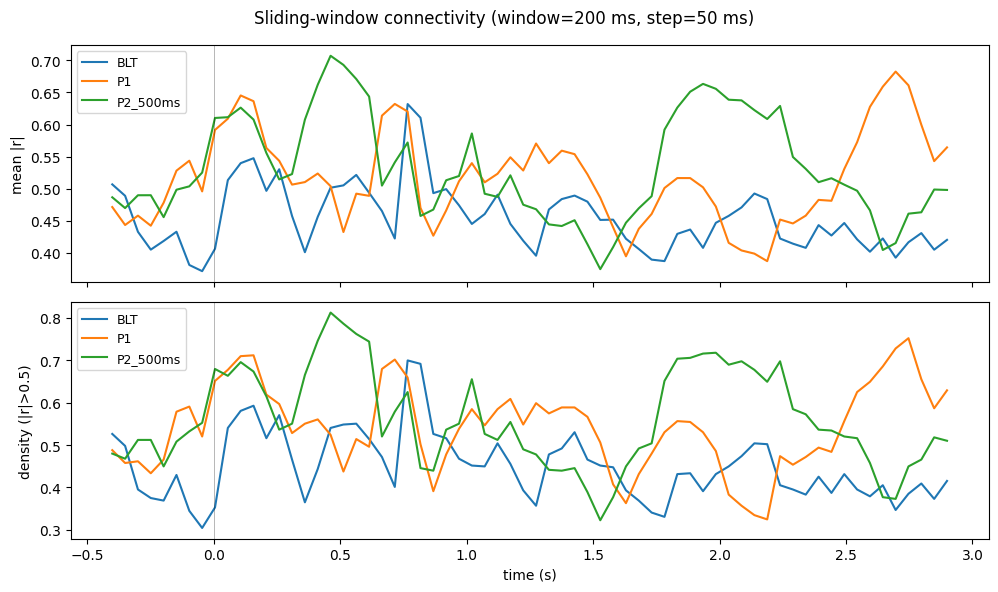

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for name, res in results.items():
    m = summary_metrics(res['corr'])
    axes[0].plot(res['centers'], m['mean_abs_r'], label=name)
    axes[1].plot(res['centers'], m['density'], label=name)
axes[0].set_ylabel('mean |r|')
axes[1].set_ylabel('density (|r|>0.5)')
axes[1].set_xlabel('time (s)')
for ax in axes:
    ax.axvline(0, color='k', lw=0.5, alpha=0.4)
    ax.legend(loc='best', fontsize=9)
fig.suptitle(f'Sliding-window connectivity (window={WINDOW_MS} ms, step={STEP_MS} ms)')
plt.tight_layout()
plt.show()

## E. Heatmap grid at key time points

Pick a few window indices and show the full `n_ch x n_ch` matrix for each condition.

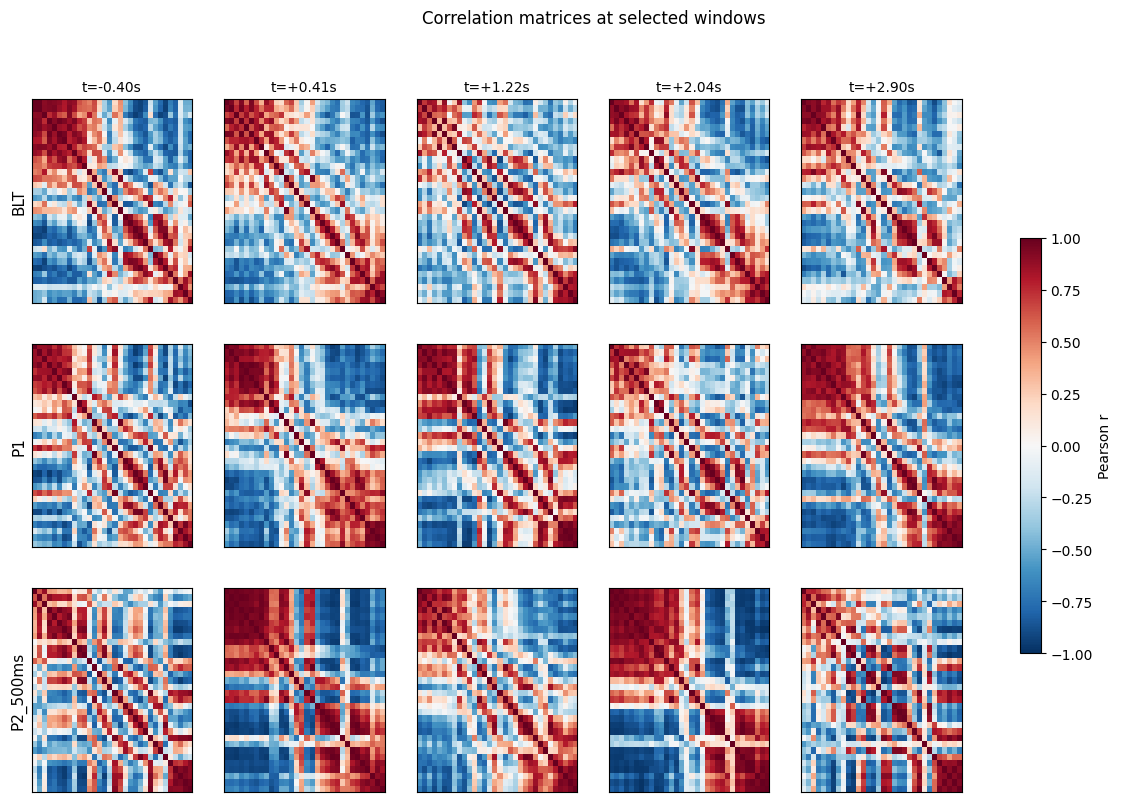

In [61]:
centers = results['BLT']['centers']
n_windows = len(centers)
# Pick 5 evenly spaced windows across the epoch.
pick_idx = np.linspace(0, n_windows - 1, 5, dtype=int)
pick_times = centers[pick_idx]

cond_names = list(results.keys())
fig, axes = plt.subplots(
    len(cond_names), len(pick_idx),
    figsize=(3.0 * len(pick_idx), 3.0 * len(cond_names)),
    squeeze=False,
)
for i, name in enumerate(cond_names):
    corr = results[name]['corr']
    for j, w in enumerate(pick_idx):
        ax = axes[i, j]
        im = ax.imshow(corr[w], vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Pearson r')
fig.suptitle('Correlation matrices at selected windows')
plt.show()

## F. Animation

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import io
from PIL import Image

centers = results['BLT']['centers']
cond_names = list(results.keys())

frame_images = []

for j in range(len(centers)):
    fig, axes = plt.subplots(
        len(cond_names), 1,
        figsize=(3.5, 3.0 * len(cond_names)),
        squeeze=False,
        constrained_layout=True,   # ← replaces tight_layout
    )

    for i, name in enumerate(cond_names):
        corr = results[name]['corr']
        ax = axes[i, 0]
        im = ax.imshow(corr[j], vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylabel(name, fontsize=11)

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Pearson r')
    fig.suptitle(f'Correlation matrices — t={centers[j]:+.2f}s', fontsize=12)
    # NO plt.tight_layout() here

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100)
    buf.seek(0)
    frame_images.append(np.array(Image.open(buf)))
    plt.close(fig)

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib import rc
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128
rc('animation', html='jshtml')

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
im = ax.imshow(frame_images[0]) 

def update(frame):
    im.set_array(frame_images[frame])
    return im,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frame_images),
    interval=200,
    blit=True,
    repeat=True
)

plt.close(fig)
HTML(ani.to_jshtml())

## F. Condition-difference heatmaps

P1 - BLT isolates the effect of adding the auditory cue (with a fixed 500 ms gap). P2_500ms - P1 isolates paradigm/block differences when the audio->tactile interval is matched.

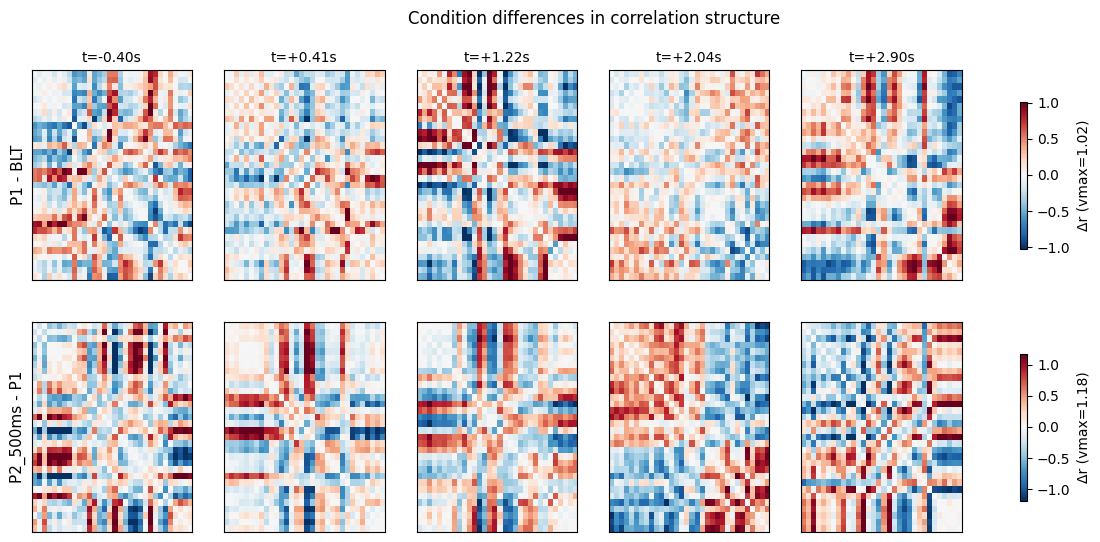

In [ ]:
diffs = {
    'P1 - BLT': results['P1']['corr'] - results['BLT']['corr'],
    'P2_500ms - P1': results['P2_500ms']['corr'] - results['P1']['corr'],
}
# Symmetric color range per diff for fair reading.
fig, axes = plt.subplots(
    len(diffs), len(pick_idx),
    figsize=(3.0 * len(pick_idx), 3.0 * len(diffs)),
    squeeze=False,
)
for i, (name, d) in enumerate(diffs.items()):
    vmax = np.nanpercentile(np.abs(d), 99)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    for j, w in enumerate(pick_idx):
        ax = axes[i, j]
        im = ax.imshow(d[w], vmin=-vmax, vmax=vmax, cmap='RdBu_r', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
    fig.colorbar(im, ax=axes[i, :].tolist(), shrink=0.7, label=f'\u0394r (vmax={vmax:.2f})')
fig.suptitle('Condition differences in correlation structure')
plt.show()

## G. (Optional) Per-band repeat

Re-run B-F with `FREQ_BAND = 'alpha'` or `'beta'` to check whether the dynamics are band-specific.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


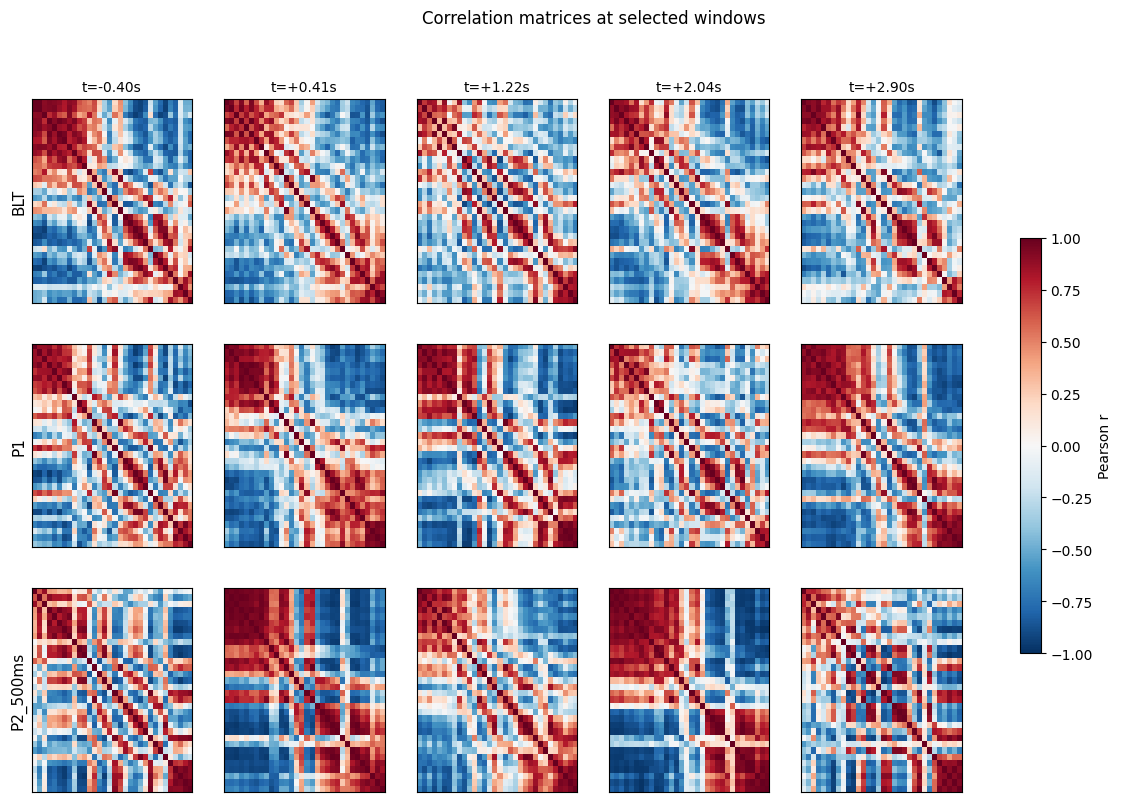

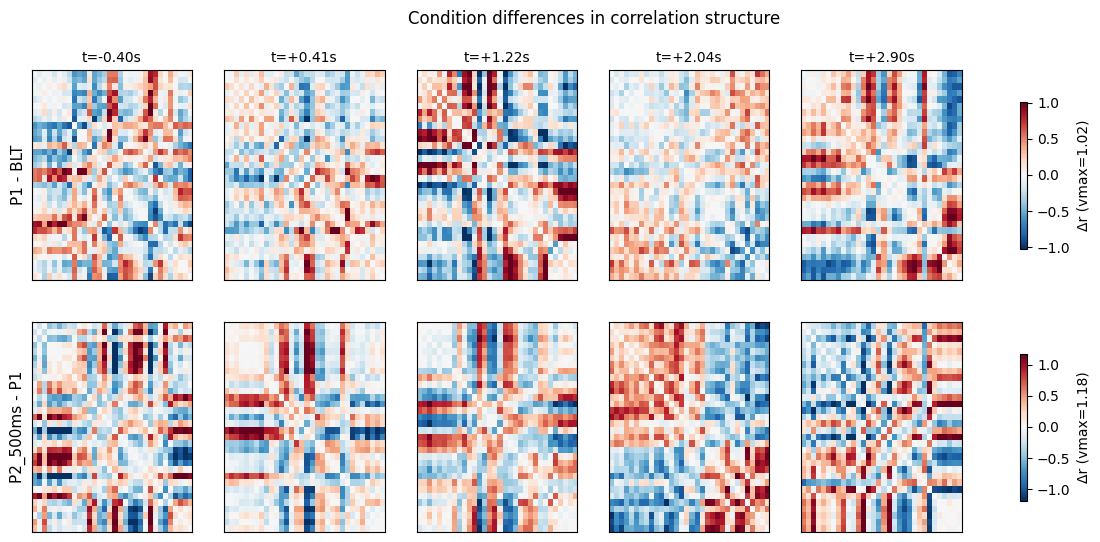

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\seanc\phys-of-cog-project\utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


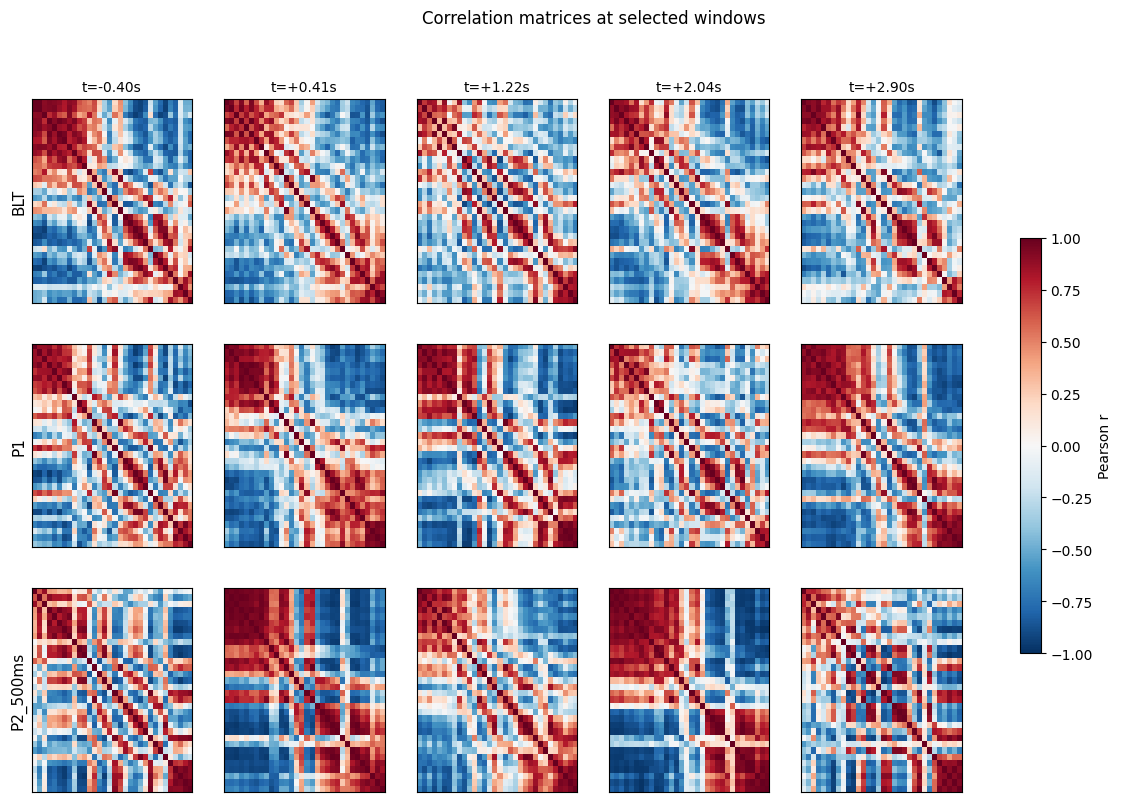

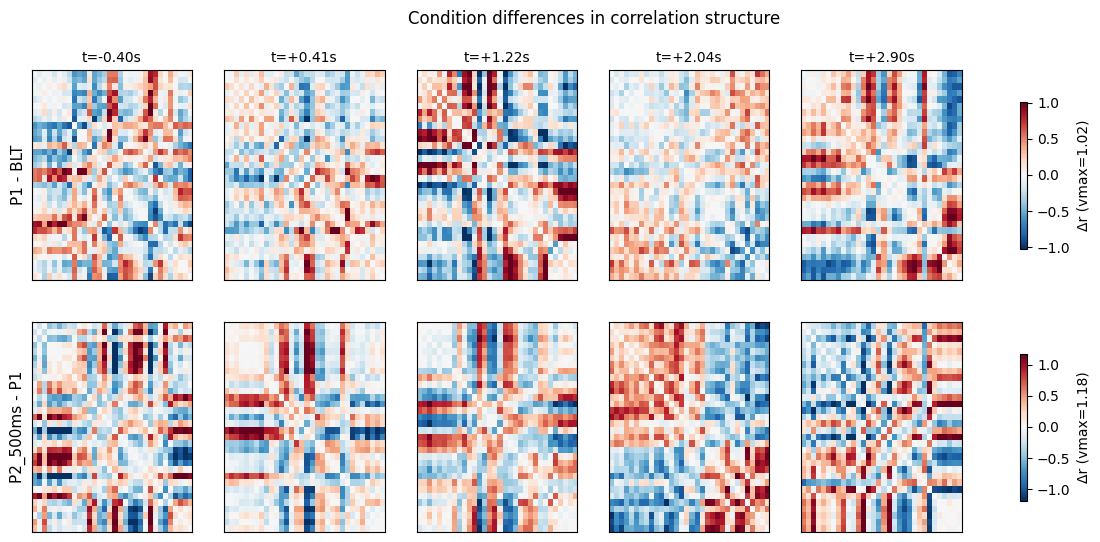

In [ ]:
frequencies = ['alpha', 'beta']
for freq in frequencies:
    blt = load_eeg_data('BLT', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band = freq, normalize=True)
    p1  = load_eeg_data('P1',  SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=freq, normalize=True)
    p2_all = load_eeg_data('P2', SUBJECT, tmin=TMIN, tmax=TMAX, freq_band=freq, normalize=True)
    p2 = select_p2_500ms(p2_all)
    
    assert np.allclose(blt.times, p1.times), 'BLT and P1 time axes differ'
    assert np.allclose(p1.times, p2.times), 'P1 and P2 time axes differ'
    
    # Channel-set alignment: intersect across files so the NxN matrices line up.
    common_ch = [c for c in blt.ch_names if c in p1.ch_names and c in p2.ch_names]
    for ep in (blt, p1, p2):
        ep.pick_channels(common_ch, ordered=True)
        
    centers = results['BLT']['centers']
    n_windows = len(centers)
    # Pick 5 evenly spaced windows across the epoch.
    pick_idx = np.linspace(0, n_windows - 1, 5, dtype=int)
    pick_times = centers[pick_idx]
    
    cond_names = list(results.keys())
    fig, axes = plt.subplots(
        len(cond_names), len(pick_idx),
        figsize=(3.0 * len(pick_idx), 3.0 * len(cond_names)),
        squeeze=False,
    )
    for i, name in enumerate(cond_names):
        corr = results[name]['corr']
        for j, w in enumerate(pick_idx):
            ax = axes[i, j]
            im = ax.imshow(corr[w], vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
            if j == 0:
                ax.set_ylabel(name, fontsize=11)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Pearson r')
    fig.suptitle('Correlation matrices at selected windows')
    plt.show()
    
    diffs = {
        'P1 - BLT': results['P1']['corr'] - results['BLT']['corr'],
        'P2_500ms - P1': results['P2_500ms']['corr'] - results['P1']['corr'],
    }
    # Symmetric color range per diff for fair reading.
    fig, axes = plt.subplots(
        len(diffs), len(pick_idx),
        figsize=(3.0 * len(pick_idx), 3.0 * len(diffs)),
        squeeze=False,
    )
    for i, (name, d) in enumerate(diffs.items()):
        vmax = np.nanpercentile(np.abs(d), 99)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0
        for j, w in enumerate(pick_idx):
            ax = axes[i, j]
            im = ax.imshow(d[w], vmin=-vmax, vmax=vmax, cmap='RdBu_r', aspect='auto')
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(f't={pick_times[j]:+.2f}s', fontsize=10)
            if j == 0:
                ax.set_ylabel(name, fontsize=11)
        fig.colorbar(im, ax=axes[i, :].tolist(), shrink=0.7, label=f'\u0394r (vmax={vmax:.2f})')
    fig.suptitle('Condition differences in correlation structure')
    plt.show()
    

## Test for Linear Lag

observe difference in correlation between lagged/unlagged, if you see uniform increase in correlation, should hint toward linear lag

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

LAGS_SEC = np.linspace(-0.02, 0.02, 81)

#conds = {'BLT': blt, 'P1': p1, 'P2_500ms': p2}
conds = {'P1': p1}
results = {}
for name, ep in conds.items():
    diff_corr, centers, ch_names = sliding_lagged_diff_corr_from_epochs(
        ep, WINDOW_MS, STEP_MS, LAGS_SEC
    )
    results[name] = {'corr': diff_corr, 'centers': centers, 'ch_names': ch_names}
    print(f'{name}: corr {diff_corr.shape}  centers [{centers[0]:.3f}s .. {centers[-1]:.3f}s]')
cond_names = list(results.keys())
ref_centers = results['P1']['centers']

# corr is now (n_windows, n_lags, n_ch, n_ch)

%matplotlib inline

ref_centers = results['P1']['centers']

all_data = np.concatenate([results[n]['corr'] for n in cond_names])
clim = np.nanpercentile(np.abs(all_data), 99)

time_slider = widgets.SelectionSlider(
    options=[(f'{t:+.2f}s', i) for i, t in enumerate(ref_centers)],
    description='Time:',
    layout=widgets.Layout(width='600px'),
)
lag_slider = widgets.SelectionSlider(
    options=[(f'{l:+.3f}s', i) for i, l in enumerate(LAGS_SEC)],
    description='Lag:',
    layout=widgets.Layout(width='600px'),
)

out = widgets.Output()

def redraw(change=None):
    time_idx = time_slider.value
    lag_idx  = lag_slider.value
    lag      = LAGS_SEC[lag_idx]
    tcen     = ref_centers[time_idx]

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(
            len(cond_names), 1,
            figsize=(5, 5 * len(cond_names)),  # square figure
            squeeze=False,
            constrained_layout=True,
        )
        for i, name in enumerate(cond_names):
            ax = axes[i, 0]
            im = ax.imshow(
                results[name]['corr'][time_idx, lag_idx],
                vmin=-clim, vmax=clim,
                cmap='RdBu_r',
                aspect='equal',   # square cells → square matrix
            )
            ax.set_xlabel('Channels (lagged)', fontsize=8)
            ax.set_ylabel(name, fontsize=11)
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Δ Pearson r')
        fig.suptitle(
            f'Lagged − Zero-lag  |  t={tcen:+.2f}s   lag={lag:+.3f}s',
            fontsize=11
        )
        plt.show()

time_slider.observe(redraw, names='value')
lag_slider.observe(redraw, names='value')

display(widgets.VBox([time_slider, lag_slider, out]))
redraw()  # draw initial frame

P1: corr (357, 81, 32, 32)  centers [-0.490s .. 2.986s]


## PLV implementation
requires mne-connectivity

In [ ]:
import mne_connectivity

from mne import BaseEpochs

def sliding_plv(epochs, window_ms, step_ms, fmin=8, fmax=30):
    """
    Compute PLV in sliding windows across the epoch time axis.
    
    Returns
    -------
    plv_matrix : (n_ch, n_ch, n_windows)
    centers    : (n_windows,) in seconds
    """
    sfreq     = epochs.info['sfreq']
    times     = epochs.times
    win_samp  = int(round(window_ms * sfreq / 1000))
    step_samp = int(round(step_ms   * sfreq / 1000))
    n_times   = len(times)
    n_ch      = len(epochs.ch_names)
    
    starts  = np.arange(0, n_times - win_samp + 1, step_samp)
    centers = times[starts + win_samp // 2]

    plv_windows = []
    for start in starts:
        t_start = times[start]
        t_end   = times[start + win_samp - 1]

        # Crop epochs to this window
        ep_win = epochs.copy().crop(tmin=t_start, tmax=t_end)

        # Compute PLV across epochs in this window
        conn = mne_connectivity.spectral_connectivity_time(
            ep_win,
            method='plv',
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax,
            faverage=True,    # average over freq band → one value
            verbose=False,
        )
        data = conn.get_data().squeeze()  # (n_connections,) = (n_ch^2,)
        plv_windows.append(data.reshape(n_ch, n_ch))

    plv_matrix = np.stack(plv_windows, axis=-1)  # (n_ch, n_ch, n_windows)
    return plv_matrix, centers


plv_matrix, plv_centers = sliding_plv(p1, WINDOW_MS, STEP_MS, fmin=8, fmax=30)
print(plv_matrix.shape)  # (32, 32, n_windows)

C:\Users\seanc\AppData\Local\Temp\ipykernel_23872\2606623166.py:33: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 60 events (all good), -0.5 – -0.303 s (baseline off), ~1.5 MiB, data loaded,
 'B7(audio1)/B1(tactile1)': 10
 'B8(audio2)/B2(tactile2)': 10
 'B9(audio3)/B3(tactile3)': 10
 'B10(audio4)/B4(tactile4)': 10
 'B11(audio5)/B5(tactile5)': 10
 'B12(audio6)/B6(tactile6)': 10>, so metadata was not modified.
  conn = mne_connectivity.spectral_connectivity_epochs(
C:\Users\seanc\AppData\Local\Temp\ipykernel_23872\2606623166.py:33: RuntimeWarning: fmin=8.000 Hz corresponds to 1.594 < 5 cycles based on the epoch length 0.199 sec, need at least 0.625 sec epochs or fmin=25.098. Spectrum estimate will be unreliable.
  conn = mne_connectivity.spectral_connectivity_epochs(
C:\Users\seanc\AppData\Local\Temp\ipykernel_23872\2606623166.py:33: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 60 events (all good), -0.449 – -0.252 s (baseline off), ~1.5 MiB, 

(32, 32, 66)


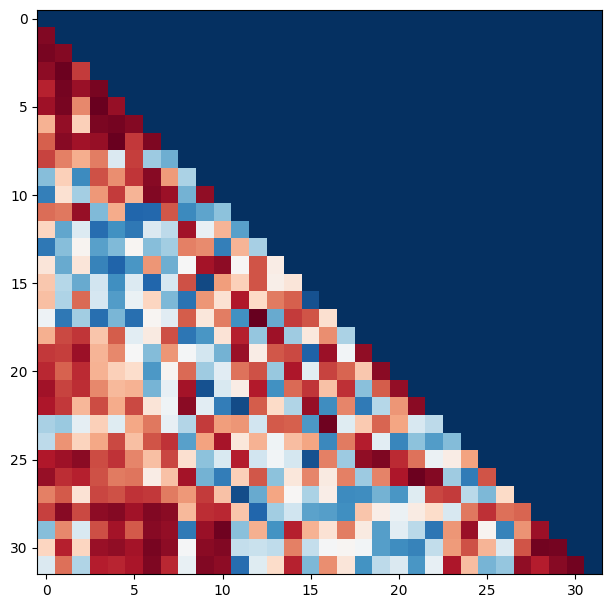

In [ ]:
time_slider = widgets.SelectionSlider(
    options=[(f'{t:+.3f}s', i) for i, t in enumerate(plv_centers)],
    description='Time:',
    layout=widgets.Layout(width='700px'),
)

out = widgets.Output()

def redraw(change=None):
    t_idx = time_slider.value
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
        im = ax.imshow(
            plv_matrix[:, :, t_idx],
            vmin=0, vmax=1,
            cmap='RdBu_r',
            aspect='equal',
        )
        ax.set_xticks(range(n_ch))
        ax.set_yticks(range(n_ch))
        ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
        ax.set_yticklabels(ch_names, fontsize=6)
        fig.colorbar(im, ax=ax, shrink=0.8, label='PLV')
        ax.set_title(f'PLV (8–30 Hz) — t={plv_centers[t_idx]:+.3f}s', fontsize=12)
        plt.show()

time_slider.observe(redraw, names='value')
display(widgets.VBox([time_slider, out]))
redraw()

##See if we can find groups that are similarly correlated?